In [17]:
import os
import pandas as pd
from typing import List, Tuple
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import json
from torch.utils.data import DataLoader
from model import LSTMQNet
import torch
from train_utils import OffPolicyTrainer
import torch.nn as nn
from world_cup_env import WorldCupEnv
from agent import DoubleDQNAgent

font = {'size': 16}

matplotlib.rc('font', **font)

In [18]:
DATASET_PATH = "../../dataset"
INDEX_FIELD = "timestamp"
DATA_FIELD = "num_request"
CPD_CANDIDATE_ROOT = "../../change_point_detection/offline_detection/cpd_candidate"
N_LOOKBACK = 4
N_PREDICT = 2


In [19]:
def get_data_file_list(dataset_path: str) -> List[str]:
    return os.listdir(dataset_path)

In [20]:
def read_dataset(csv_path: str,index_field:str,data_field:str) -> Tuple[np.ndarray, np.ndarray]:
    df = pd.read_csv(csv_path)
    return df[index_field].to_numpy(), df[data_field].to_numpy()

In [21]:
def read_candidate_cpds(path: str) -> List[int]:
    candidate_cpds = None
    with open(path, "r") as f:
        candidate_cpds = json.load(f)
    return candidate_cpds

In [22]:
def build_dataset(np_data: np.ndarray, candidate_cpds: List[int]):
    x = []
    y = []
    candidate_cpds = np.array(candidate_cpds, dtype=np.int32)
    np_data = np_data/20000.0
    for idx in range(len(np_data)-N_LOOKBACK-N_PREDICT+2):
        x.append(np_data[idx:idx+N_LOOKBACK+N_PREDICT-1].reshape((-1, 1)))
        is_less = candidate_cpds < idx+N_LOOKBACK+N_PREDICT
        future_candidate_idx = np.sum(is_less)
        if future_candidate_idx < len(candidate_cpds):
            nearest_cpd = candidate_cpds[future_candidate_idx]
            if nearest_cpd > idx + N_LOOKBACK+N_PREDICT+N_PREDICT:
                y.append(0)
            elif nearest_cpd >= idx + N_LOOKBACK+N_PREDICT:
                y.append(1)
            # else:
            #     y.append(2)
        else:
            y.append(0)
    # x = np.array(x)
    # y = np.array(y)
    return x, y

In [23]:
workload_to_skip_list = ["workload_1998-06-13", "workload_1998-06-14", "workload_1998-06-20", "workload_1998-06-21", "workload_1998-06-27", "workload_1998-06-28","workload_1998-07-04"]

read workload_1998-06-10.csv
eval results: reward -22.131188


eval results: reward -22.131188
read workload_1998-06-11.csv
eval results: reward -14.923295
eval results: reward -14.923295
read workload_1998-06-12.csv
eval results: reward -19.374539
eval results: reward -19.374539
read workload_1998-06-15.csv
eval results: reward -23.146537
eval results: reward -23.146537
read workload_1998-06-16.csv
eval results: reward -8.830542
eval results: reward -8.830542
read workload_1998-06-17.csv
eval results: reward -10.710458
eval results: reward -10.710458
read workload_1998-06-18.csv
eval results: reward -5.736026
eval results: reward -5.736026
read workload_1998-06-19.csv
eval results: reward -7.866515
eval results: reward -7.866515
read workload_1998-06-22.csv
eval results: reward -10.151297
eval results: reward -10.151297
read workload_1998-06-23.csv
eval results: reward -21.170342
eval results: reward -21.170342
read workload_1998-06-24.csv
eval results: reward -20.861755
eval results: reward -20.861755
read workload_1998-06-25.csv
eval results: r

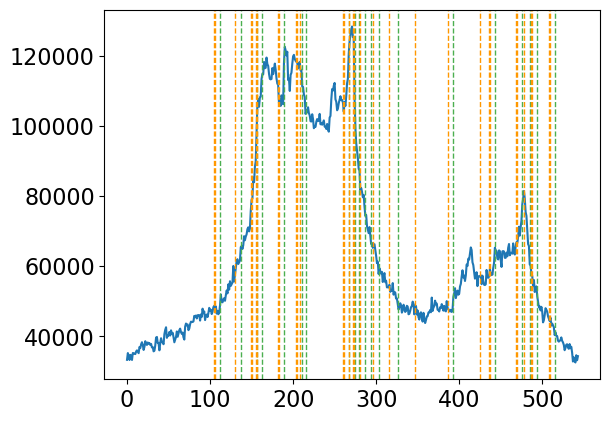

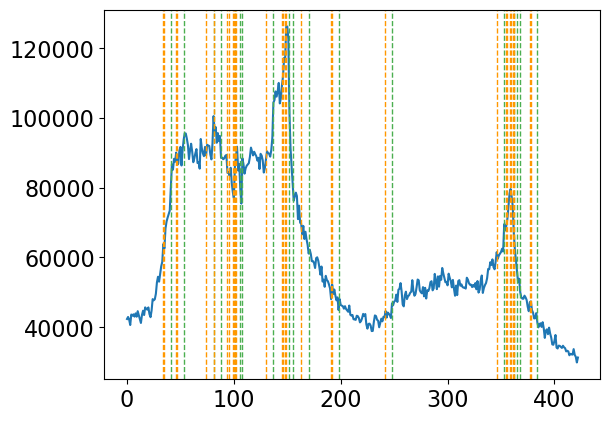

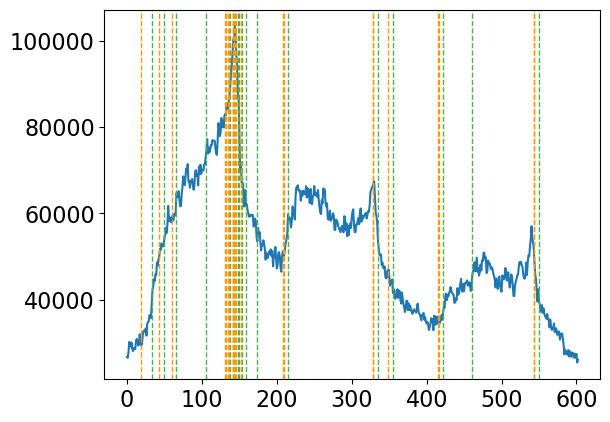

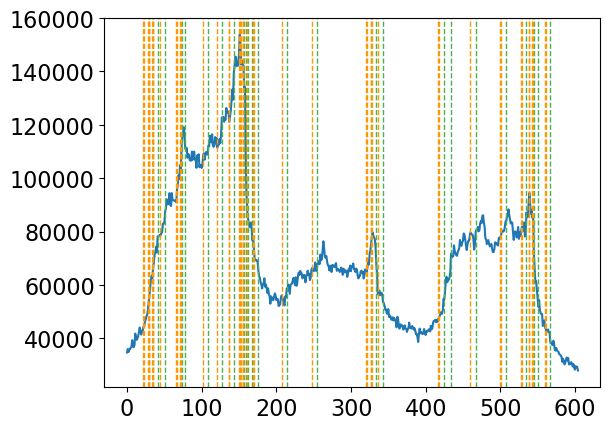

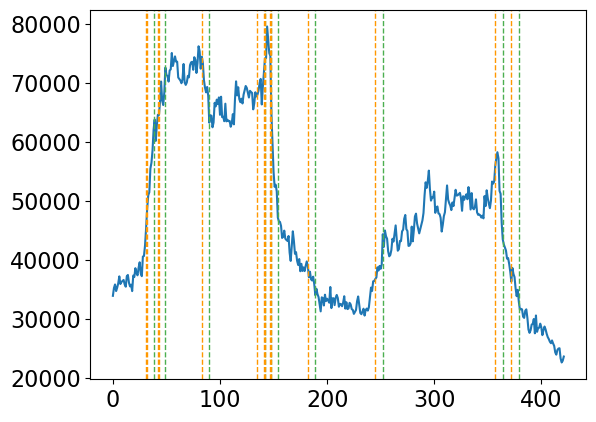

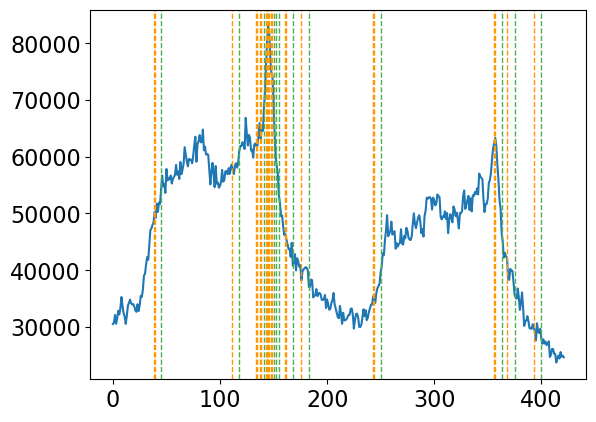

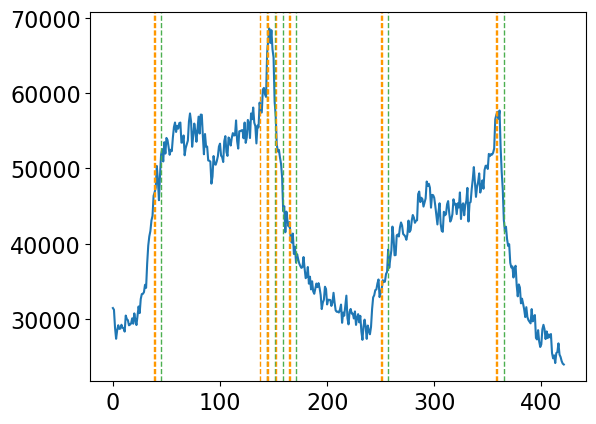

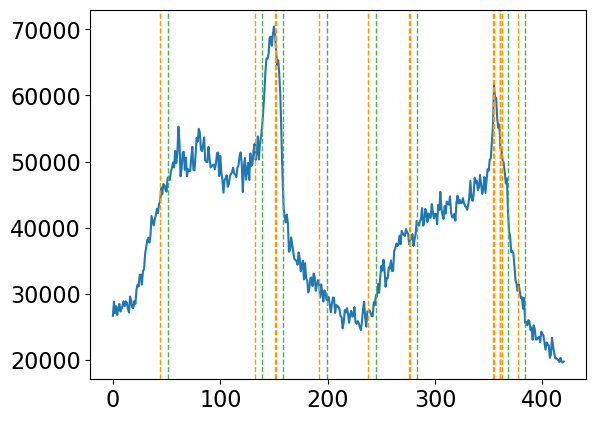

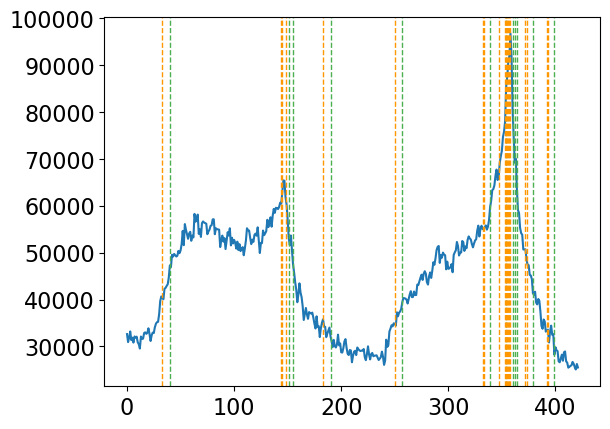

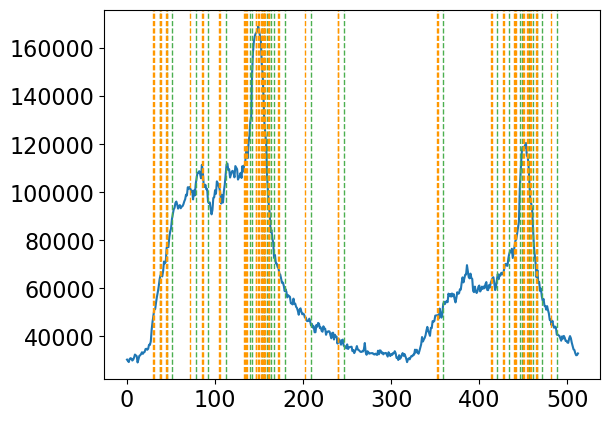

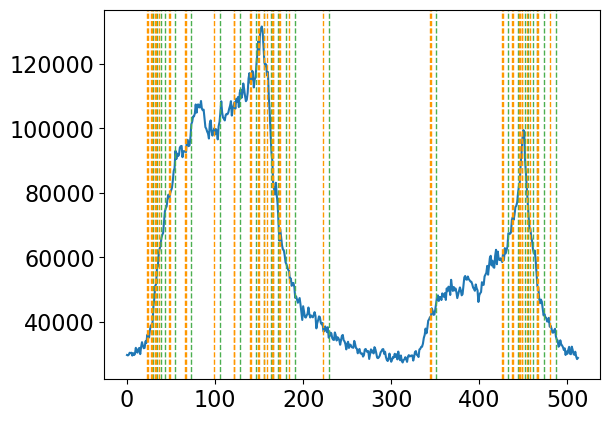

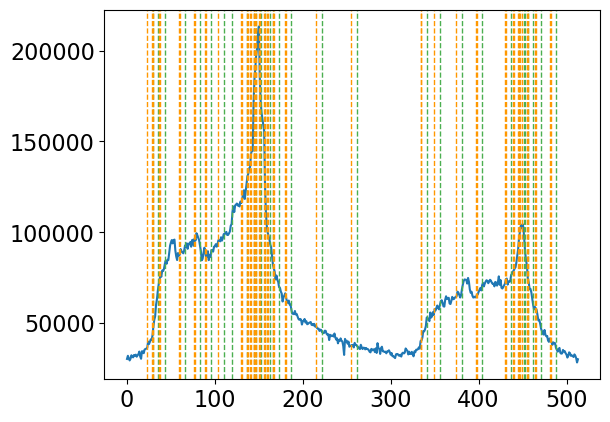

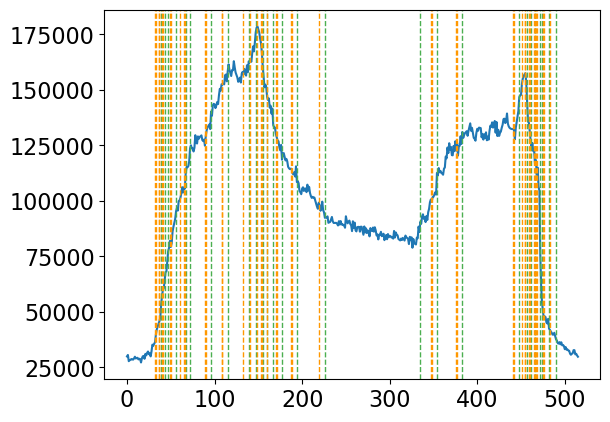

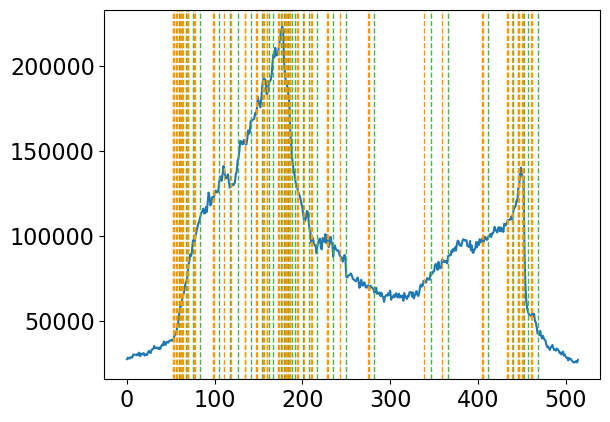

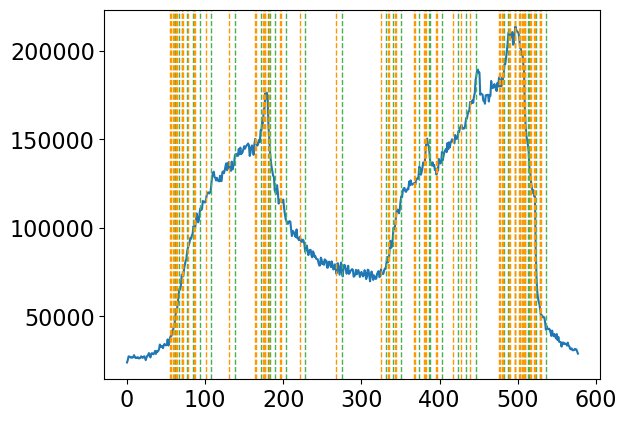

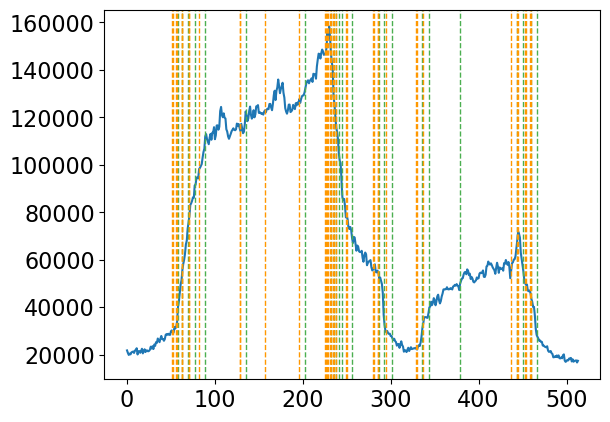

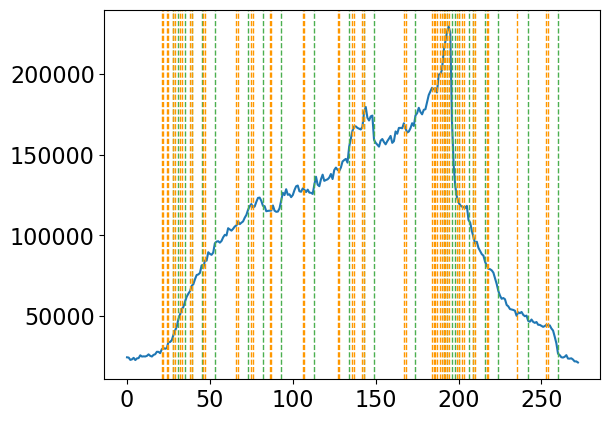

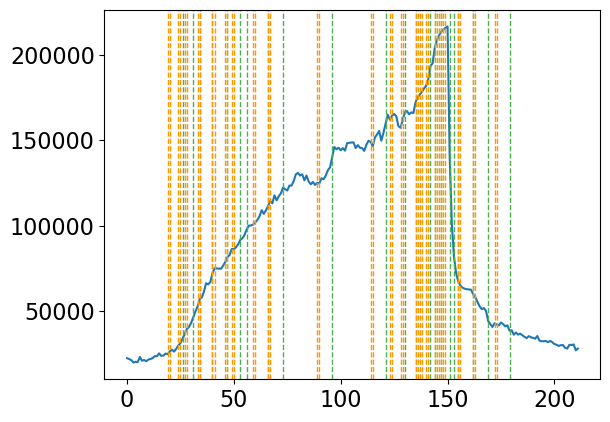

In [24]:
import json
data_file_list = get_data_file_list(DATASET_PATH)
state_list = None
action_list = None
env = None
agent = DoubleDQNAgent(2)
# agent.load("state_dict/"+"all_200"+".pth")
trainer = OffPolicyTrainer(env, agent, num_episodes=100, replay_buffer_size=128, batch_size=32, discount_factor=0.9, epsilon_start=0.5, epsilon_end=0.1, epsilon_step=20, learning_rate_start=1e-3, learning_rate_end=1e-4, learning_rate_step=100, tau=0.05)
for file_name in data_file_list:
    workload_name = file_name.split(".")[0]
    if workload_name in workload_to_skip_list:
        continue
    print("read %s" % (file_name))
    np_index, np_data = read_dataset(os.path.join(DATASET_PATH, file_name), INDEX_FIELD, DATA_FIELD)
    np_data = np_data/20000.0
    workload_diff = np.diff(np_data).reshape((-1, 1))
    candidate_cpds = read_candidate_cpds(os.path.join(CPD_CANDIDATE_ROOT, workload_name+".json"))
    env = WorldCupEnv(workload_diff, candidate_cpds, N_LOOKBACK, N_PREDICT)
    agent.load("state_dict/"+workload_name+".pth")
    trainer.set_env(env)
    trainer.eval()
    state_list, action_list = trainer.eval()
    np_data = np_data*20000.0
    fig,ax=plt.subplots()
    cpds_pd=np.where(np.array(action_list)==1)[0]
    ax.plot(np_data)
    for cp in candidate_cpds:
        ax.axvline(x=cp, color="#4CAF50", linestyle='--', linewidth=1)
    for cp in cpds_pd:
        ax.axvline(x=cp, color="#FF9800", linestyle='--', linewidth=1)
    